# K-Means Clustering - Amazon User Segmentation
**Dataset:** Amazon.com Clustering Model (200 customers)

## Importing Required Libraries

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np


## Importing (Reading) Datasets

In [2]:
data = pd.read_csv('Amazon.com Clusturing Model.csv')
print(data)


     Cus_ID Sex  Age   Income  Rating
0    301264   F   49   303051       1
1    301358   M   35   303267      59
2    301398   M   46   305486      39
3    301305   F   53   309435      74
4    301413   M   35   338102      23
..      ...  ..  ...      ...     ...
195  301404   M   46  2719862      12
196  301339   F   52  2750976      69
197  301295   F   39  2770784      15
198  301284   F   49  2775648      85
199  301282   M   19  2791518      21

[200 rows x 5 columns]


## Assigning Independent Variable

In [3]:
x = data.iloc[:, [2, 4]].values


## Number of Clusters via Elbow Method

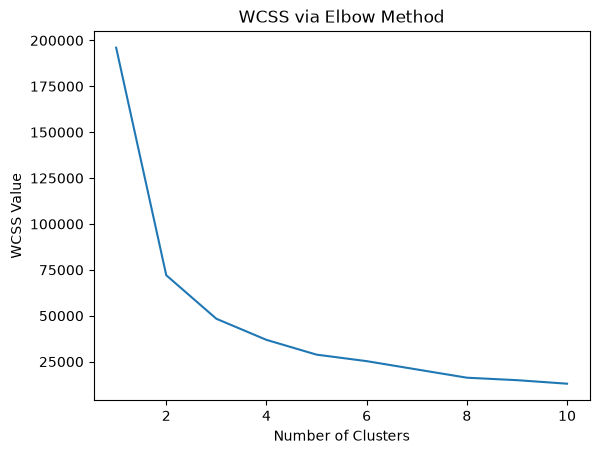

In [4]:
wcss = []
for i in range(1, 11):
    model = KMeans(n_clusters=i, init='k-means++', random_state=21)
    model.fit(x)
    wcss.append(model.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('WCSS via Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS Value')
plt.show()


## K-Means Clustering on Training Set

In [5]:
model = KMeans(n_clusters=4, init='k-means++', random_state=42)
y_means = model.fit_predict(x)
print('y_means:\n\n', y_means)


y_means:

 [3 0 1 2 3 3 1 1 3 2 2 0 2 0 2 2 2 1 2 3 1 1 3 0 1 0 1 0 2 1 0 1 0 3 3 0 3
 3 1 2 3 3 1 2 3 2 3 3 2 3 1 3 3 3 3 2 0 3 2 3 0 2 2 3 2 0 1 2 3 3 1 2 3 1
 0 1 1 2 2 1 1 3 3 2 1 1 1 1 2 0 1 3 1 1 3 0 3 1 2 1 1 1 2 3 3 2 3 3 1 1 1
 3 2 3 1 0 3 3 1 1 3 2 2 0 1 1 1 3 3 0 1 3 3 3 3 3 1 1 2 2 3 1 0 1 1 3 3 2
 1 2 3 3 1 1 1 0 2 1 0 1 0 0 3 0 2 3 0 2 0 1 3 3 3 3 2 2 3 3 3 1 0 3 0 0 2
 1 3 3 2 3 0 3 3 1 3 3 2 3 2 3]


## Scattering the Clusters

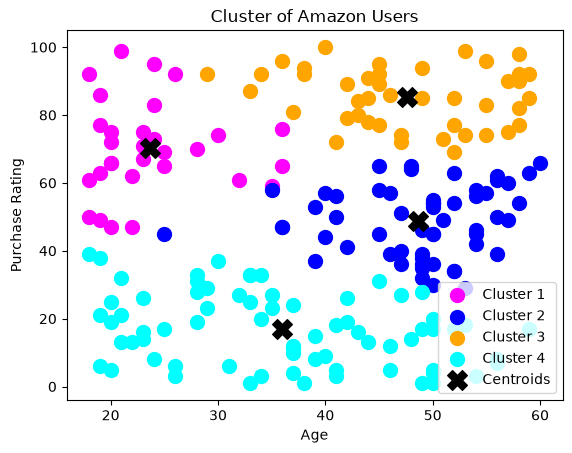

In [6]:
plt.scatter(x[y_means == 0, 0], x[y_means == 0, 1], s=100, c='magenta', label='Cluster 1')
plt.scatter(x[y_means == 1, 0], x[y_means == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(x[y_means == 2, 0], x[y_means == 2, 1], s=100, c='orange', label='Cluster 3')
plt.scatter(x[y_means == 3, 0], x[y_means == 3, 1], s=100, c='cyan', label='Cluster 4')
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroids')
plt.title('Cluster of Amazon Users')
plt.xlabel('Age')
plt.ylabel('Purchase Rating')
plt.legend()
plt.show()
